In [2]:
from sklearn.preprocessing import StandardScaler
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import torch
import os
import joblib

In [2]:
#step3_sliding_window

In [3]:
uk = pd.read_csv("/root/uk_full.csv")
ie = pd.read_csv("/root/ie_full.csv")

uk["valid_time"] = pd.to_datetime(uk["valid_time"])
ie["valid_time"] = pd.to_datetime(ie["valid_time"])

print("UK shape:", uk.shape)
print("IE shape:", ie.shape)
print("列名:", list(uk.columns))

UK shape: (49000392, 10)
IE shape: (9210600, 10)
列名: ['valid_time', 'latitude', 'longitude', 'u10', 'v10', 'd2m', 't2m', 'sp', 'tcc', 'tp']


In [4]:
WINDOW = 12      # 输入12小时
LEAD = 1         # 预测t+1
FEATURES = ['u10', 'v10', 'd2m', 't2m', 'sp', 'tcc', 'tp']

def build_sliding_window(df, window=WINDOW, lead=LEAD, features=FEATURES):
    """
    对每个网格点独立构造滑动窗口样本
    输入X: [样本数, window, n_features]
    标签y: [样本数] (t+lead时刻的tp)
    """
    all_X = []
    all_y = []
    
    # 获取所有唯一网格点
    grid_points = df.groupby(['latitude', 'longitude'])
    total = len(grid_points)
    
    print(f"共{total}个网格点，开始构造滑动窗口...")
    
    for i, ((lat, lon), group) in enumerate(grid_points):
        if i % 500 == 0:
            print(f"  进度: {i}/{total}")
        
        # 按时间排序
        group = group.sort_values("valid_time").reset_index(drop=True)
        data = group[features].values  # [T, n_features]
        tp = group['tp'].values        # [T]
        
        T = len(data)
        for t in range(window, T - lead + 1):
            X = data[t-window:t]       # [window, n_features]
            y = tp[t + lead - 1]       # 标量
            all_X.append(X)
            all_y.append(y)
    
    X_arr = np.array(all_X, dtype=np.float32)
    y_arr = np.array(all_y, dtype=np.float32)
    print(f"完成！X shape: {X_arr.shape}, y shape: {y_arr.shape}")
    return X_arr, y_arr

print("函数定义完成")

函数定义完成


In [5]:
print("开始构造UK滑动窗口样本...")
X_uk, y_uk = build_sliding_window(uk)

print("\n开始构造Ireland滑动窗口样本...")
X_ie, y_ie = build_sliding_window(ie)

print("\n=== 最终结果 ===")
print(f"X_uk shape: {X_uk.shape}")
print(f"y_uk shape: {y_uk.shape}")
print(f"X_ie shape: {X_ie.shape}")
print(f"y_ie shape: {y_ie.shape}")

开始构造UK滑动窗口样本...
共2793个网格点，开始构造滑动窗口...
  进度: 0/2793
  进度: 500/2793
  进度: 1000/2793
  进度: 1500/2793
  进度: 2000/2793
  进度: 2500/2793
完成！X shape: (48966876, 12, 7), y shape: (48966876,)

开始构造Ireland滑动窗口样本...
共525个网格点，开始构造滑动窗口...
  进度: 0/525
  进度: 500/525
完成！X shape: (9204300, 12, 7), y shape: (9204300,)

=== 最终结果 ===
X_uk shape: (48966876, 12, 7)
y_uk shape: (48966876,)
X_ie shape: (9204300, 12, 7)
y_ie shape: (9204300,)


In [6]:
print("保存中...")
np.save("/root/X_uk.npy", X_uk)
np.save("/root/y_uk.npy", y_uk)
np.save("/root/X_ie.npy", X_ie)
np.save("/root/y_ie.npy", y_ie)
print("保存完成！")

保存中...
保存完成！


In [ ]:
#步骤4：划分train/val/test

In [7]:
# 重新构造时间索引
# 每个网格点有17532个样本(17544-12)，按时间顺序排列
N_TIMES = 17544 - WINDOW  # = 17532，每个网格点的样本数
N_GRID_UK = 2793
N_GRID_IE = 525

# 构造对应的时间戳序列（每个样本对应的预测时刻）
uk_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
ie_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")

# UK划分索引
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"

# Ireland划分索引
ie_train_mask = ie_times < "2021-01-01"
ie_val_mask   = (ie_times >= "2021-01-01") & (ie_times < "2021-07-01")
ie_test_mask  = ie_times >= "2021-07-01"

# 因为样本是按网格点排列的，需要展开索引
def split_by_time_mask(X, y, mask, n_grid, n_times):
    """
    X: [n_grid * n_times, 12, 7]
    按时间mask提取对应样本
    """
    idx = np.where(np.tile(mask, n_grid))[0]
    return X[idx], y[idx]

X_uk_train, y_uk_train = split_by_time_mask(X_uk, y_uk, uk_train_mask, N_GRID_UK, N_TIMES)
X_uk_val,   y_uk_val   = split_by_time_mask(X_uk, y_uk, uk_val_mask,   N_GRID_UK, N_TIMES)
X_uk_test,  y_uk_test  = split_by_time_mask(X_uk, y_uk, uk_test_mask,  N_GRID_UK, N_TIMES)

X_ie_train, y_ie_train = split_by_time_mask(X_ie, y_ie, ie_train_mask, N_GRID_IE, N_TIMES)
X_ie_val,   y_ie_val   = split_by_time_mask(X_ie, y_ie, ie_val_mask,   N_GRID_IE, N_TIMES)
X_ie_test,  y_ie_test  = split_by_time_mask(X_ie, y_ie, ie_test_mask,  N_GRID_IE, N_TIMES)

print("=== 划分结果 ===")
print(f"UK train: {X_uk_train.shape}, val: {X_uk_val.shape}, test: {X_uk_test.shape}")
print(f"IE train: {X_ie_train.shape}, val: {X_ie_val.shape}, test: {X_ie_test.shape}")

=== 划分结果 ===
UK train: (24497403, 12, 7), val: (12132792, 12, 7), test: (12336681, 12, 7)
IE train: (4604775, 12, 7), val: (2280600, 12, 7), test: (2318925, 12, 7)


In [ ]:
#步骤5：标准化

In [11]:
# 用memmap读取，不占内存
X_uk = np.load("/root/X_uk.npy", mmap_mode='r')
y_uk = np.load("/root/y_uk.npy", mmap_mode='r')
X_ie = np.load("/root/X_ie.npy", mmap_mode='r')
y_ie = np.load("/root/y_ie.npy", mmap_mode='r')

# 时间划分索引
N_TIMES = 17532
N_GRID_UK = 2793
N_GRID_IE = 525

import pandas as pd
uk_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
ie_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
ie_train_mask = ie_times < "2021-01-01"

# 只用train部分拟合scaler
train_idx_uk = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
train_idx_ie = np.where(np.tile(ie_train_mask, N_GRID_IE))[0]

# 取train数据做fit（reshape成2D）
print("fitting scaler on UK train...")
X_uk_train_2d = X_uk[train_idx_uk].reshape(-1, 7)
scaler_X = StandardScaler()
scaler_X.fit(X_uk_train_2d)
del X_uk_train_2d

print("fitting scaler on y...")
scaler_y = StandardScaler()
scaler_y.fit(y_uk[train_idx_uk].reshape(-1, 1))

# 保存scaler
joblib.dump(scaler_X, "/root/scaler_X.pkl")
joblib.dump(scaler_y, "/root/scaler_y.pkl")
print("scaler保存完成！")
print("scaler_X mean:", scaler_X.mean_)
print("scaler_y mean:", scaler_y.mean_)

fitting scaler on UK train...
fitting scaler on y...
scaler保存完成！
scaler_X mean: [2.29442240e+00 1.36668514e+00 2.80252034e+02 2.83541504e+02
 1.00637618e+05 7.08279882e-01 1.36034096e-04]
scaler_y mean: [0.00013611]


In [ ]:
步骤6：Deterministic baseline

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

# 基本设置
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", DEVICE)

# 加载scaler
scaler_X = joblib.load("/root/scaler_X.pkl")
scaler_y = joblib.load("/root/scaler_y.pkl")

# 加载数据
X_uk = np.load("/root/X_uk.npy", mmap_mode='r')
y_uk = np.load("/root/y_uk.npy", mmap_mode='r')

# 时间索引
N_TIMES = 17532
N_GRID_UK = 2793
uk_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"

train_idx = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx   = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx  = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print("数据加载完成")

使用设备: cuda
Train: 24497403, Val: 12132792, Test: 12336681
数据加载完成


In [2]:
# Dataset
class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        # 取出对应索引的数据并标准化
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# 模型：简单LSTM
class DeterministicLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

print("Dataset和模型定义完成")

Dataset和模型定义完成


In [3]:
# 创建Dataset（注意：2400万样本，初始化会花几分钟）
print("创建Dataset...")
train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
print("DataLoader创建完成")

创建Dataset...
Train dataset: 24497403
Val dataset:   12132792
DataLoader创建完成


In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
from sklearn.metrics import r2_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", DEVICE)

scaler_X = joblib.load("/root/scaler_X.pkl")
scaler_y = joblib.load("/root/scaler_y.pkl")

X_uk = np.load("/root/X_uk.npy", mmap_mode='r')
y_uk = np.load("/root/y_uk.npy", mmap_mode='r')

N_TIMES = 17532
N_GRID_UK = 2793
uk_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
uk_train_mask = uk_times < "2021-01-01"
uk_val_mask   = (uk_times >= "2021-01-01") & (uk_times < "2021-07-01")
uk_test_mask  = uk_times >= "2021-07-01"
train_idx = np.where(np.tile(uk_train_mask, N_GRID_UK))[0]
val_idx   = np.where(np.tile(uk_val_mask,   N_GRID_UK))[0]
test_idx  = np.where(np.tile(uk_test_mask,  N_GRID_UK))[0]

class RainfallDataset(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class DeterministicLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

print("创建Dataset...")
train_dataset = RainfallDataset(X_uk, y_uk, train_idx, scaler_X, scaler_y)
val_dataset   = RainfallDataset(X_uk, y_uk, val_idx,   scaler_X, scaler_y)
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
print("准备完成，开始训练...")

model = DeterministicLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/root/best_deterministic.pth")
        print(f"  ✓ 保存最优模型")

print("训练完成！")

使用设备: cuda
创建Dataset...
准备完成，开始训练...
Epoch 1/10 | Train Loss: 0.2587 | Val Loss: 0.1717
  ✓ 保存最优模型
Epoch 2/10 | Train Loss: 0.2367 | Val Loss: 0.1725
Epoch 3/10 | Train Loss: 0.2267 | Val Loss: 0.1735
Epoch 4/10 | Train Loss: 0.2184 | Val Loss: 0.1789
Epoch 5/10 | Train Loss: 0.2122 | Val Loss: 0.1765
Epoch 6/10 | Train Loss: 0.2076 | Val Loss: 0.1831
Epoch 7/10 | Train Loss: 0.2036 | Val Loss: 0.1831
Epoch 8/10 | Train Loss: 0.2007 | Val Loss: 0.1839
Epoch 9/10 | Train Loss: 0.1979 | Val Loss: 0.1849
Epoch 10/10 | Train Loss: 0.1958 | Val Loss: 0.1903
训练完成！


In [5]:
model = DeterministicLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

EPOCHS = 30
best_val_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/root/best_deterministic.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.2776 | Val Loss: 0.1712
  ✓ 保存最优模型 (val_loss=0.1712)
Epoch 2/30 | Train Loss: 0.2490 | Val Loss: 0.1727
Epoch 3/30 | Train Loss: 0.2421 | Val Loss: 0.1736
Epoch 4/30 | Train Loss: 0.2367 | Val Loss: 0.1762
Epoch 5/30 | Train Loss: 0.2323 | Val Loss: 0.1790
Epoch 6/30 | Train Loss: 0.2285 | Val Loss: 0.1809
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.1712


In [6]:
# 加载最优模型评估test set
model.load_state_dict(torch.load("/root/best_deterministic.pth"))
model.eval()

test_dataset = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader  = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)

all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch).cpu().numpy()
        all_preds.append(pred)
        all_true.append(y_batch.numpy())

preds = np.concatenate(all_preds)
trues = np.concatenate(all_true)

# 反标准化
preds_orig = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse = np.sqrt(np.mean((preds_orig - trues_orig)**2))
r2   = r2_score(trues_orig, preds_orig)

print(f"=== Deterministic LSTM Test Results ===")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.4f}")

=== Deterministic LSTM Test Results ===
RMSE: 0.000193
R²:   0.7168


In [ ]:
#步骤7：Uncertainty-aware baseline（mean+variance）

In [7]:
class UncertaintyLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_mean = nn.Linear(hidden_size, 1)
        self.fc_var  = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        mean = self.fc_mean(h).squeeze(-1)
        var  = torch.nn.functional.softplus(self.fc_var(h)).squeeze(-1) + 1e-6
        return mean, var

def nll_loss(mean, var, target):
    """负对数似然损失（高斯假设）"""
    return (torch.log(var) + (target - mean)**2 / var).mean()

model_unc = UncertaintyLSTM().to(DEVICE)
optimizer_unc = torch.optim.Adam(model_unc.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_unc.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_unc.zero_grad()
        mean, var = model_unc(X_batch)
        loss = nll_loss(mean, var, y_batch)
        loss.backward()
        optimizer_unc.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_unc.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            mean, var = model_unc(X_batch)
            val_loss += nll_loss(mean, var, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_unc.state_dict(), "/root/best_uncertainty.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: -2.6001 | Val Loss: -2.6979
  ✓ 保存最优模型 (val_loss=-2.6979)
Epoch 2/30 | Train Loss: -2.9479 | Val Loss: -1.6524
Epoch 3/30 | Train Loss: -3.0428 | Val Loss: -2.5617
Epoch 4/30 | Train Loss: -3.0884 | Val Loss: -2.3955
Epoch 5/30 | Train Loss: -3.1571 | Val Loss: -2.3892
Epoch 6/30 | Train Loss: -3.2125 | Val Loss: -0.2886
早停！连续5个epoch没有改善
训练完成！最优Val Loss: -2.6979


In [8]:
model_unc.load_state_dict(torch.load("/root/best_uncertainty.pth"))
model_unc.eval()

all_means, all_vars, all_true = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        mean, var = model_unc(X_batch)
        all_means.append(mean.cpu().numpy())
        all_vars.append(var.cpu().numpy())
        all_true.append(y_batch.numpy())

means = np.concatenate(all_means)
vars_ = np.concatenate(all_vars)
trues = np.concatenate(all_true)

# 反标准化
means_orig = scaler_y.inverse_transform(means.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse = np.sqrt(np.mean((means_orig - trues_orig)**2))
r2   = r2_score(trues_orig, means_orig)

print(f"=== Uncertainty-aware Baseline Test Results ===")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.4f}")
print(f"Mean predicted variance: {vars_.mean():.4f}")

=== Uncertainty-aware Baseline Test Results ===
RMSE: 0.000224
R²:   0.6191
Mean predicted variance: 0.3094


In [ ]:
#步骤8：Quantile模型（q10/q50/q90）

In [9]:
class QuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        q10 = self.fc_q10(h).squeeze(-1)
        q50 = self.fc_q50(h).squeeze(-1)
        q90 = self.fc_q90(h).squeeze(-1)
        return q10, q50, q90

def pinball_loss(pred, target, quantile):
    err = target - pred
    return torch.where(err >= 0, quantile * err, (quantile - 1) * err).mean()

def quantile_loss(q10, q50, q90, target):
    return pinball_loss(q10, target, 0.1) + \
           pinball_loss(q50, target, 0.5) + \
           pinball_loss(q90, target, 0.9)

model_q = QuantileLSTM().to(DEVICE)
optimizer_q = torch.optim.Adam(model_q.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_q.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q.zero_grad()
        q10, q50, q90 = model_q(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_q.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_q.state_dict(), "/root/best_quantile.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.1981 | Val Loss: 0.1409
  ✓ 保存最优模型 (val_loss=0.1409)
Epoch 2/30 | Train Loss: 0.1792 | Val Loss: 0.1395
  ✓ 保存最优模型 (val_loss=0.1395)
Epoch 3/30 | Train Loss: 0.1769 | Val Loss: 0.1390
  ✓ 保存最优模型 (val_loss=0.1390)
Epoch 4/30 | Train Loss: 0.1754 | Val Loss: 0.1387
  ✓ 保存最优模型 (val_loss=0.1387)
Epoch 5/30 | Train Loss: 0.1743 | Val Loss: 0.1394
Epoch 6/30 | Train Loss: 0.1734 | Val Loss: 0.1391
Epoch 7/30 | Train Loss: 0.1726 | Val Loss: 0.1393
Epoch 8/30 | Train Loss: 0.1719 | Val Loss: 0.1395
Epoch 9/30 | Train Loss: 0.1712 | Val Loss: 0.1399
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.1387


In [10]:
model_q.load_state_dict(torch.load("/root/best_quantile.pth"))
model_q.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s = np.concatenate(all_q10)
q50s = np.concatenate(all_q50)
q90s = np.concatenate(all_q90)
trues = np.concatenate(all_true)

# 反标准化
q50_orig  = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2   = r2_score(trues_orig, q50_orig)

# 覆盖率：真实值落在q10~q90之间的比例（理想值=80%）
q10_orig = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q90_orig = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Quantile Model Test Results ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage (q10-q90): {coverage:.4f} (理想值=0.80)")

=== Quantile Model Test Results ===
RMSE:     0.000194
R²:       0.7130
Coverage (q10-q90): 0.8474 (理想值=0.80)


In [ ]:
#步骤9：Physics-guided Quantile

In [11]:
class PhysicsGuidedQuantileLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        
        # 物理gate：用最后时间步的tcwv(index=6 is tp, sp=4, tcc=5)
        # 输入：tcc + sp → gate值
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
        self.fc_q10 = nn.Linear(hidden_size, 1)
        self.fc_q50 = nn.Linear(hidden_size, 1)
        self.fc_q90 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        
        # 物理gate：取最后时间步的tcc(index=5)和sp(index=4)
        tcc_sp = x[:, -1, 4:6]  # [batch, 2]
        gate = self.gate_fc(tcc_sp)  # [batch, 1]
        
        # gate调制输出
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

def physics_quantile_loss(q10, q50, q90, target, gate, extreme_threshold=0.95):
    """
    Pinball loss + extreme weighting
    强降雨样本权重加倍
    """
    # 基础pinball loss
    base_loss = (pinball_loss(q10, target, 0.1) +
                 pinball_loss(q50, target, 0.5) +
                 pinball_loss(q90, target, 0.9))
    
    # extreme weighting：强降雨样本加权
    threshold = torch.quantile(target, extreme_threshold)
    extreme_mask = (target > threshold).float()
    extreme_weight = 1.0 + 2.0 * extreme_mask
    
    weighted_loss = (pinball_loss(q10, target, 0.1) * extreme_weight +
                     pinball_loss(q50, target, 0.5) * extreme_weight +
                     pinball_loss(q90, target, 0.9) * extreme_weight).mean()
    
    return base_loss + 0.5 * weighted_loss

model_pg = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_pg = torch.optim.Adam(model_pg.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_pg.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_pg.zero_grad()
        q10, q50, q90, gate = model_pg(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_pg.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_pg.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_pg(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_pg.state_dict(), "/root/best_physics_quantile.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.3090 | Val Loss: 0.2186
  ✓ 保存最优模型 (val_loss=0.2186)
Epoch 2/30 | Train Loss: 0.2775 | Val Loss: 0.2158
  ✓ 保存最优模型 (val_loss=0.2158)
Epoch 3/30 | Train Loss: 0.2740 | Val Loss: 0.2165
Epoch 4/30 | Train Loss: 0.2718 | Val Loss: 0.2162
Epoch 5/30 | Train Loss: 0.2700 | Val Loss: 0.2150
  ✓ 保存最优模型 (val_loss=0.2150)
Epoch 6/30 | Train Loss: 0.2685 | Val Loss: 0.2153
Epoch 7/30 | Train Loss: 0.2671 | Val Loss: 0.2156
Epoch 8/30 | Train Loss: 0.2659 | Val Loss: 0.2158
Epoch 9/30 | Train Loss: 0.2648 | Val Loss: 0.2153
Epoch 10/30 | Train Loss: 0.2638 | Val Loss: 0.2158
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.2150


In [12]:
model_pg.load_state_dict(torch.load("/root/best_physics_quantile.pth"))
model_pg.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s  = np.concatenate(all_q10)
q50s  = np.concatenate(all_q50)
q90s  = np.concatenate(all_q90)
trues = np.concatenate(all_true)

q10_orig  = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig  = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Physics-guided Quantile Test Results ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage (q10-q90): {coverage:.4f} (理想值=0.80)")

=== Physics-guided Quantile Test Results ===
RMSE:     0.000196
R²:       0.7076
Coverage (q10-q90): 0.8293 (理想值=0.80)


In [ ]:
#步骤10：Ireland-only baseline

In [13]:
# 步骤10：Ireland-only baseline
# 加载Ireland数据
X_ie = np.load("/root/X_ie.npy", mmap_mode='r')
y_ie = np.load("/root/y_ie.npy", mmap_mode='r')

N_GRID_IE = 525
ie_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
ie_train_mask = ie_times < "2021-01-01"
ie_val_mask   = (ie_times >= "2021-01-01") & (ie_times < "2021-07-01")
ie_test_mask  = ie_times >= "2021-07-01"

ie_train_idx = np.where(np.tile(ie_train_mask, N_GRID_IE))[0]
ie_val_idx   = np.where(np.tile(ie_val_mask,   N_GRID_IE))[0]
ie_test_idx  = np.where(np.tile(ie_test_mask,  N_GRID_IE))[0]

print(f"IE Train: {len(ie_train_idx)}, Val: {len(ie_val_idx)}, Test: {len(ie_test_idx)}")

# 用Ireland数据的scaler（用IE train拟合）
from sklearn.preprocessing import StandardScaler
import joblib

scaler_X_ie = StandardScaler()
scaler_y_ie = StandardScaler()

X_ie_train_2d = X_ie[ie_train_idx].reshape(-1, 7)
scaler_X_ie.fit(X_ie_train_2d)
del X_ie_train_2d

scaler_y_ie.fit(y_ie[ie_train_idx].reshape(-1, 1))

joblib.dump(scaler_X_ie, "/root/scaler_X_ie.pkl")
joblib.dump(scaler_y_ie, "/root/scaler_y_ie.pkl")
print("Ireland scaler保存完成")

# 创建Dataset
ie_train_dataset = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_dataset   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)
ie_test_dataset  = RainfallDataset(X_ie, y_ie, ie_test_idx,  scaler_X_ie, scaler_y_ie)

ie_train_loader = DataLoader(ie_train_dataset, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_loader   = DataLoader(ie_val_dataset,   batch_size=4096, shuffle=False, num_workers=4)
ie_test_loader  = DataLoader(ie_test_dataset,  batch_size=4096, shuffle=False, num_workers=4)
print("Ireland DataLoader创建完成")

# 训练Physics-guided Quantile模型（Ireland-only）
model_ie = PhysicsGuidedQuantileLSTM().to(DEVICE)
optimizer_ie = torch.optim.Adam(model_ie.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ie.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ie.zero_grad()
        q10, q50, q90, gate = model_ie(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ie.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_loader)

    model_ie.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ie(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_ie.state_dict(), "/root/best_ie_only.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

IE Train: 4604775, Val: 2280600, Test: 2318925
Ireland scaler保存完成
Ireland DataLoader创建完成
Epoch 1/30 | Train Loss: 0.4198 | Val Loss: 0.2318
  ✓ 保存最优模型 (val_loss=0.2318)
Epoch 2/30 | Train Loss: 0.2991 | Val Loss: 0.2237
  ✓ 保存最优模型 (val_loss=0.2237)
Epoch 3/30 | Train Loss: 0.2912 | Val Loss: 0.2200
  ✓ 保存最优模型 (val_loss=0.2200)
Epoch 4/30 | Train Loss: 0.2870 | Val Loss: 0.2191
  ✓ 保存最优模型 (val_loss=0.2191)
Epoch 5/30 | Train Loss: 0.2842 | Val Loss: 0.2191
  ✓ 保存最优模型 (val_loss=0.2191)
Epoch 6/30 | Train Loss: 0.2819 | Val Loss: 0.2189
  ✓ 保存最优模型 (val_loss=0.2189)
Epoch 7/30 | Train Loss: 0.2801 | Val Loss: 0.2186
  ✓ 保存最优模型 (val_loss=0.2186)
Epoch 8/30 | Train Loss: 0.2784 | Val Loss: 0.2194
Epoch 9/30 | Train Loss: 0.2769 | Val Loss: 0.2205
Epoch 10/30 | Train Loss: 0.2755 | Val Loss: 0.2214
Epoch 11/30 | Train Loss: 0.2741 | Val Loss: 0.2216
Epoch 12/30 | Train Loss: 0.2729 | Val Loss: 0.2228
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.2186


In [14]:
model_ie.load_state_dict(torch.load("/root/best_ie_only.pth"))
model_ie.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ie(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig  = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig  = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Ireland-only Test Results (上限参考) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== Ireland-only Test Results (上限参考) ===
RMSE:     0.000210
R²:       0.6928
Coverage: 0.8620 (理想值=0.80)


In [ ]:
# 步骤11：UK-only zero-shot
# 直接用步骤9的UK模型在Ireland测试集上评估
# 注意：用UK的scaler，因为模型是在UK数据上训练的

In [15]:
# 重新创建Ireland测试集，但用UK的scaler
class RainfallDatasetUKScaler(Dataset):
    def __init__(self, X, y, idx, scaler_X, scaler_y):
        X_data = X[idx].reshape(-1, 7)
        X_data = scaler_X.transform(X_data).reshape(-1, 12, 7)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        y_data = y[idx].reshape(-1, 1)
        y_data = scaler_y.transform(y_data).reshape(-1)
        self.y = torch.tensor(y_data, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# 用UK scaler处理Ireland测试数据
ie_test_uk_scaler = RainfallDatasetUKScaler(
    X_ie, y_ie, ie_test_idx, scaler_X, scaler_y)
ie_test_uk_loader = DataLoader(
    ie_test_uk_scaler, batch_size=4096, shuffle=False, num_workers=4)

# 加载UK训练的Physics-guided模型
model_pg.load_state_dict(torch.load("/root/best_physics_quantile.pth"))
model_pg.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== UK Zero-shot on Ireland Test Results (迁移下限) ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== UK Zero-shot on Ireland Test Results (迁移下限) ===
RMSE:     0.000210
R²:       0.6938
Coverage: 0.8314 (理想值=0.80)


In [ ]:
# 步骤12：UK→Ireland fine-tune
# 用Ireland train数据微调UK预训练模型

In [16]:
# 加载UK预训练模型
model_ft = PhysicsGuidedQuantileLSTM().to(DEVICE)
model_ft.load_state_dict(torch.load("/root/best_physics_quantile.pth"))

# 微调：用更小的学习率
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=1e-4)

# 用Ireland的scaler
ie_train_ft = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_ft   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)

ie_train_ft_loader = DataLoader(ie_train_ft, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_ft_loader   = DataLoader(ie_val_ft,   batch_size=4096, shuffle=False, num_workers=4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_ft.zero_grad()
        q10, q50, q90, gate = model_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_ft.state_dict(), "/root/best_finetune.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.2725 | Val Loss: 0.2151
  ✓ 保存最优模型 (val_loss=0.2151)
Epoch 2/30 | Train Loss: 0.2714 | Val Loss: 0.2153
Epoch 3/30 | Train Loss: 0.2706 | Val Loss: 0.2159
Epoch 4/30 | Train Loss: 0.2699 | Val Loss: 0.2166
Epoch 5/30 | Train Loss: 0.2693 | Val Loss: 0.2165
Epoch 6/30 | Train Loss: 0.2688 | Val Loss: 0.2174
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.2151


In [17]:
model_ft.load_state_dict(torch.load("/root/best_finetune.pth"))
model_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []

with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== UK→Ireland Fine-tune Test Results ===")
print(f"RMSE:     {rmse:.6f}")
print(f"R²:       {r2:.4f}")
print(f"Coverage: {coverage:.4f} (理想值=0.80)")

=== UK→Ireland Fine-tune Test Results ===
RMSE:     0.000209
R²:       0.6966
Coverage: 0.8264 (理想值=0.80)


In [ ]:
# 步骤13：强降雨分析

In [18]:
# 定义强降雨阈值：使用Ireland测试集tp的95%分位数
threshold = np.percentile(trues_orig, 95)
print(f"强降雨阈值 (95th percentile): {threshold:.6f} m/hr")

def extreme_metrics(q50, q90, trues, threshold):
    """
    强降雨专项指标
    """
    extreme_mask = trues >= threshold
    n_extreme = extreme_mask.sum()
    print(f"强降雨样本数: {n_extreme} ({n_extreme/len(trues)*100:.2f}%)")
    
    # 1. 强降雨POD (Probability of Detection)
    # q90超过阈值算预测到
    hit = ((q90 >= threshold) & extreme_mask).sum()
    pod = hit / n_extreme
    
    # 2. 强降雨FAR (False Alarm Rate)
    false_alarm = ((q90 >= threshold) & ~extreme_mask).sum()
    total_alarm = (q90 >= threshold).sum()
    far = false_alarm / total_alarm if total_alarm > 0 else 0
    
    # 3. 强降雨CSI (Critical Success Index)
    miss = ((q90 < threshold) & extreme_mask).sum()
    csi = hit / (hit + false_alarm + miss)
    
    # 4. 强降雨RMSE
    extreme_rmse = np.sqrt(np.mean((q50[extreme_mask] - trues[extreme_mask])**2))
    
    return pod, far, csi, extreme_rmse

print("\n=== 强降雨分析结果 ===")
print("\n--- Ireland本地训练 ---")
# 重新获取Ireland本地训练的预测结果
model_ie.load_state_dict(torch.load("/root/best_ie_only.pth"))
model_ie.eval()
all_q50_ie, all_q90_ie, all_true_ie = [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ie(X_batch)
        all_q50_ie.append(q50.cpu().numpy())
        all_q90_ie.append(q90.cpu().numpy())
        all_true_ie.append(y_batch.numpy())
q50_ie = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ie).reshape(-1,1)).reshape(-1)
q90_ie = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ie).reshape(-1,1)).reshape(-1)
true_ie = scaler_y_ie.inverse_transform(np.concatenate(all_true_ie).reshape(-1,1)).reshape(-1)
threshold = np.percentile(true_ie, 95)
print(f"阈值: {threshold:.6f}")
pod, far, csi, ext_rmse = extreme_metrics(q50_ie, q90_ie, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

print("\n--- UK Zero-shot ---")
model_pg.load_state_dict(torch.load("/root/best_physics_quantile.pth"))
model_pg.eval()
all_q50_zs, all_q90_zs = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_pg(X_batch)
        all_q50_zs.append(q50.cpu().numpy())
        all_q90_zs.append(q90.cpu().numpy())
q50_zs = scaler_y.inverse_transform(np.concatenate(all_q50_zs).reshape(-1,1)).reshape(-1)
q90_zs = scaler_y.inverse_transform(np.concatenate(all_q90_zs).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_zs, q90_zs, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

print("\n--- UK→Ireland Fine-tune ---")
model_ft.load_state_dict(torch.load("/root/best_finetune.pth"))
model_ft.eval()
all_q50_ft, all_q90_ft = [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_ft(X_batch)
        all_q50_ft.append(q50.cpu().numpy())
        all_q90_ft.append(q90.cpu().numpy())
q50_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q50_ft).reshape(-1,1)).reshape(-1)
q90_ft = scaler_y_ie.inverse_transform(np.concatenate(all_q90_ft).reshape(-1,1)).reshape(-1)
pod, far, csi, ext_rmse = extreme_metrics(q50_ft, q90_ft, true_ie, threshold)
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨阈值 (95th percentile): 0.000787 m/hr

=== 强降雨分析结果 ===

--- Ireland本地训练 ---
阈值: 0.000787
强降雨样本数: 115994 (5.00%)
POD: 0.8835 | FAR: 0.5494 | CSI: 0.4254 | Extreme RMSE: 0.000791

--- UK Zero-shot ---
强降雨样本数: 115994 (5.00%)
POD: 0.8793 | FAR: 0.5367 | CSI: 0.4356 | Extreme RMSE: 0.000809

--- UK→Ireland Fine-tune ---
强降雨样本数: 115994 (5.00%)
POD: 0.8786 | FAR: 0.5355 | CSI: 0.4365 | Extreme RMSE: 0.000803


In [ ]:
# 普通Quantile模型 zero-shot

In [19]:
model_q.load_state_dict(torch.load("/root/best_quantile.pth"))
model_q.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_uk_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig  = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig  = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print("=== 普通Quantile Zero-shot ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 115994 (5.00%)
=== 普通Quantile Zero-shot ===
RMSE: 0.000208 | R²: 0.6994 | Coverage: 0.8466
POD: 0.8787 | FAR: 0.5373 | CSI: 0.4349 | Extreme RMSE: 0.000794


In [ ]:
# 补充实验：普通Quantile模型 fine-tune

In [20]:
model_q_ft = QuantileLSTM().to(DEVICE)
model_q_ft.load_state_dict(torch.load("/root/best_quantile.pth"))
optimizer_q_ft = torch.optim.Adam(model_q_ft.parameters(), lr=1e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

# 用Ireland scaler的DataLoader
ie_train_q = RainfallDataset(X_ie, y_ie, ie_train_idx, scaler_X_ie, scaler_y_ie)
ie_val_q   = RainfallDataset(X_ie, y_ie, ie_val_idx,   scaler_X_ie, scaler_y_ie)
ie_train_q_loader = DataLoader(ie_train_q, batch_size=4096, shuffle=True,  num_workers=4)
ie_val_q_loader   = DataLoader(ie_val_q,   batch_size=4096, shuffle=False, num_workers=4)

for epoch in range(EPOCHS):
    model_q_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_q_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_q_ft.zero_grad()
        q10, q50, q90 = model_q_ft(X_batch)
        loss = quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        optimizer_q_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_q_loader)

    model_q_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_q_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90 = model_q_ft(X_batch)
            val_loss += quantile_loss(q10, q50, q90, y_batch).item()
    val_loss /= len(ie_val_q_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_q_ft.state_dict(), "/root/best_quantile_finetune.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.1772 | Val Loss: 0.1387
  ✓ 保存最优模型 (val_loss=0.1387)
Epoch 2/30 | Train Loss: 0.1765 | Val Loss: 0.1391
Epoch 3/30 | Train Loss: 0.1761 | Val Loss: 0.1395
Epoch 4/30 | Train Loss: 0.1757 | Val Loss: 0.1393
Epoch 5/30 | Train Loss: 0.1754 | Val Loss: 0.1398
Epoch 6/30 | Train Loss: 0.1751 | Val Loss: 0.1403
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.1387


In [21]:
model_q_ft.load_state_dict(torch.load("/root/best_quantile_finetune.pth"))
model_q_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90 = model_q_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig  = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig  = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print("=== 普通Quantile Fine-tune ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 115994 (5.00%)
=== 普通Quantile Fine-tune ===
RMSE: 0.000209 | R²: 0.6980 | Coverage: 0.8426
POD: 0.8831 | FAR: 0.5430 | CSI: 0.4310 | Extreme RMSE: 0.000798


In [ ]:
#步骤14：Case study可视化。

In [33]:
import pandas as pd
import numpy as np

ie = pd.read_csv("/root/ie_full.csv")
ie["valid_time"] = pd.to_datetime(ie["valid_time"])
print("IE shape:", ie.shape)

# 取西海岸网格点（降雨最多）
target_lat = 52.5
target_lon = -11.0

ie_point = ie[(ie["latitude"] == target_lat) & 
              (ie["longitude"] == target_lon)].copy()
ie_point = ie_point.sort_values("valid_time").reset_index(drop=True)
ie_point_test = ie_point[ie_point["valid_time"] >= "2021-07-01"].reset_index(drop=True)

print(f"网格点测试集时间步: {len(ie_point_test)}")
print(f"时间范围: {ie_point_test['valid_time'].min()} to {ie_point_test['valid_time'].max()}")
print(f"最大tp: {ie_point_test['tp'].max():.6f}")

WINDOW = 12
FEATURES = ['u10', 'v10', 'd2m', 't2m', 'sp', 'tcc', 'tp']
data = ie_point_test[FEATURES].values
tp_true = ie_point_test['tp'].values
times = ie_point_test['valid_time'].values

X_point, y_point, t_point = [], [], []
for t in range(WINDOW, len(data)-1):
    X_point.append(data[t-WINDOW:t])
    y_point.append(tp_true[t])
    t_point.append(times[t])

X_point = np.array(X_point, dtype=np.float32)
y_point = np.array(y_point, dtype=np.float32)
t_point = np.array(t_point)

print(f"样本数: {len(y_point)}")
print(f"最大降水: {y_point.max():.6f}")

IE shape: (9210600, 10)
网格点测试集时间步: 4416
时间范围: 2021-07-01 00:00:00 to 2021-12-31 23:00:00
最大tp: 0.004977
样本数: 4403
最大降水: 0.004977


峰值时间: 2021-08-20T08:00:00.000000
峰值降水: 0.004977


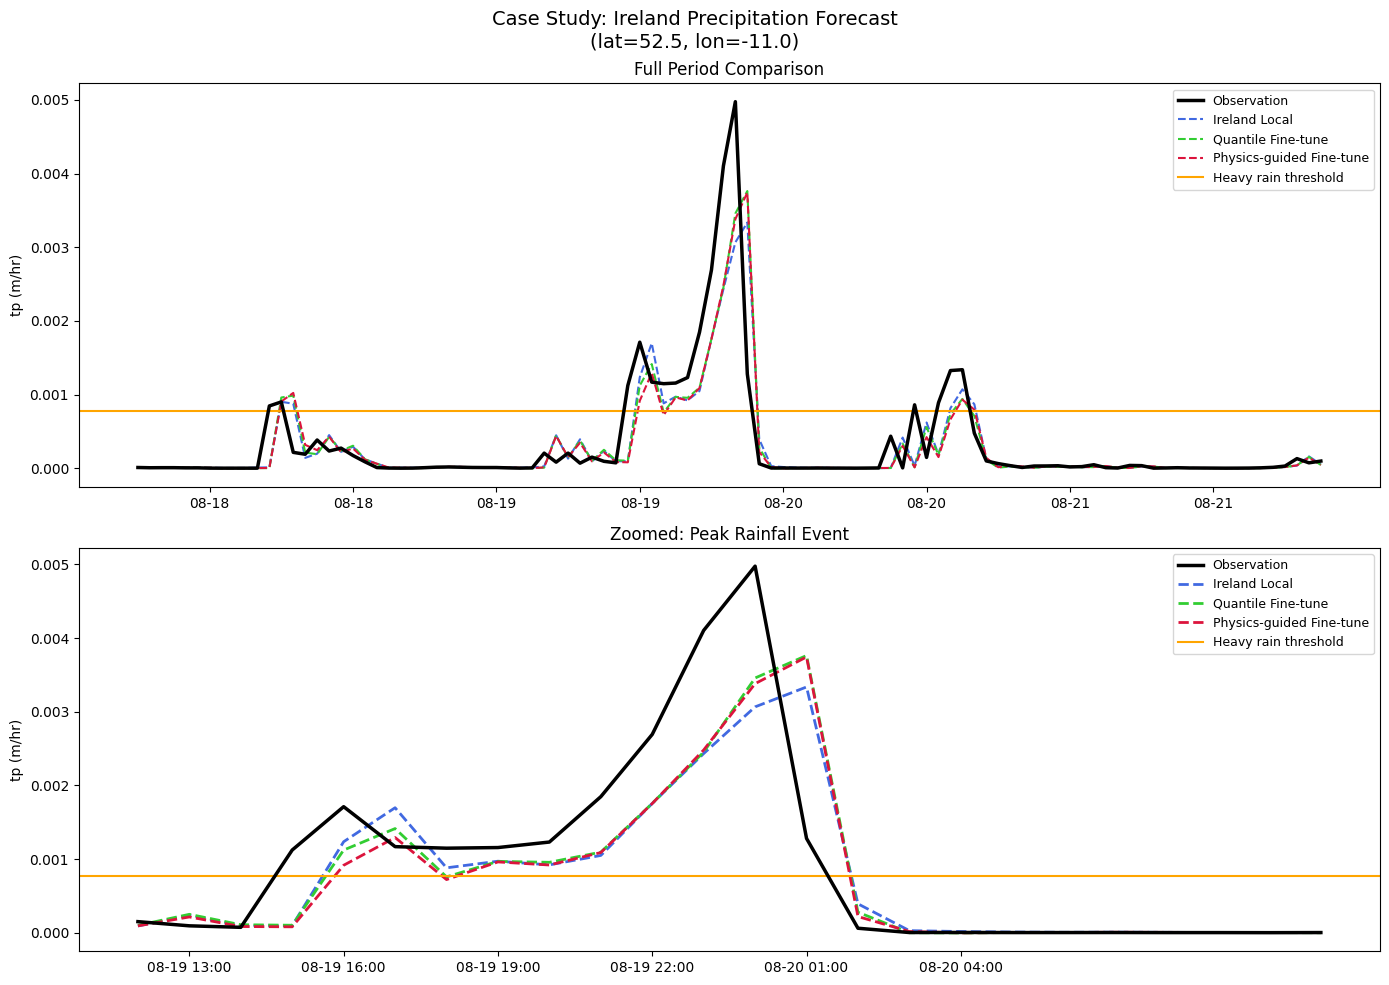

Done!


In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import joblib

plt.rcParams['font.family'] = 'DejaVu Sans'

scaler_X_ie = joblib.load("/root/scaler_X_ie.pkl")
scaler_y_ie = joblib.load("/root/scaler_y_ie.pkl")

X_point_scaled = scaler_X_ie.transform(X_point.reshape(-1,7)).reshape(-1,12,7)
X_tensor = torch.tensor(X_point_scaled, dtype=torch.float32).to(DEVICE)

model_ft.eval()
model_q_ft.eval()
model_ie.eval()

with torch.no_grad():
    q10_pg, q50_pg, q90_pg, _ = model_ft(X_tensor)
    q10_q,  q50_q,  q90_q     = model_q_ft(X_tensor)
    q10_ie, q50_ie, q90_ie, _ = model_ie(X_tensor)

def inv(arr):
    return scaler_y_ie.inverse_transform(
        arr.cpu().numpy().reshape(-1,1)).reshape(-1)

q50_pg=inv(q50_pg); q10_pg=inv(q10_pg); q90_pg=inv(q90_pg)
q50_q=inv(q50_q);   q10_q=inv(q10_q);   q90_q=inv(q90_q)
q50_ie=inv(q50_ie); q10_ie=inv(q10_ie); q90_ie=inv(q90_ie)
y_true = y_point  # 已经是原始单位

peak_idx = np.argmax(y_true)
start = max(0, peak_idx - 50)
end   = min(len(y_true), peak_idx + 50)
t_plot = pd.to_datetime(t_point[start:end])
threshold = np.percentile(y_true, 95)

print(f"峰值时间: {t_point[peak_idx]}")
print(f"峰值降水: {y_true[peak_idx]:.6f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 上图：完整100小时
ax1.plot(t_plot, y_true[start:end], 'k-', linewidth=2.5, label='Observation', zorder=5)
ax1.plot(t_plot, q50_ie[start:end], color='royalblue', linestyle='--', linewidth=1.5, label='Ireland Local')
ax1.plot(t_plot, q50_q[start:end],  color='limegreen', linestyle='--', linewidth=1.5, label='Quantile Fine-tune')
ax1.plot(t_plot, q50_pg[start:end], color='crimson',   linestyle='--', linewidth=1.5, label='Physics-guided Fine-tune')
ax1.axhline(y=threshold, color='orange', linestyle='-', linewidth=1.5, label='Heavy rain threshold')
ax1.set_ylabel('tp (m/hr)')
ax1.set_title('Full Period Comparison')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 下图：峰值放大
zoom_start = max(0, peak_idx - start - 12)
zoom_end   = min(end - start, peak_idx - start + 12)

ax2.plot(t_plot[zoom_start:zoom_end], y_true[start:end][zoom_start:zoom_end],
         'k-', linewidth=2.5, label='Observation', zorder=5)
ax2.plot(t_plot[zoom_start:zoom_end], q50_ie[start:end][zoom_start:zoom_end],
         color='royalblue', linestyle='--', linewidth=2, label='Ireland Local')
ax2.plot(t_plot[zoom_start:zoom_end], q50_q[start:end][zoom_start:zoom_end],
         color='limegreen', linestyle='--', linewidth=2, label='Quantile Fine-tune')
ax2.plot(t_plot[zoom_start:zoom_end], q50_pg[start:end][zoom_start:zoom_end],
         color='crimson', linestyle='--', linewidth=2, label='Physics-guided Fine-tune')
ax2.axhline(y=threshold, color='orange', linestyle='-', linewidth=1.5, label='Heavy rain threshold')
ax2.set_ylabel('tp (m/hr)')
ax2.set_title('Zoomed: Peak Rainfall Event')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

plt.suptitle(
    f'Case Study: Ireland Precipitation Forecast\n(lat={target_lat}, lon={target_lon})',
    fontsize=14)
plt.tight_layout()
plt.savefig("/root/case_study_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [ ]:
# 步骤15：Gate分析（替代完整SHAP，更直接）

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 用整个Ireland测试集计算gate值
X_ie = np.load("/root/X_ie.npy", mmap_mode='r')
y_ie = np.load("/root/y_ie.npy", mmap_mode='r')

N_TIMES = 17532
N_GRID_IE = 525
ie_times = pd.date_range("2020-01-01 13:00", periods=N_TIMES, freq="h")
ie_test_mask = (ie_times >= "2021-07-01") & (ie_times <= "2021-12-31 23:00")
ie_test_idx = np.where(np.tile(ie_test_mask, N_GRID_IE))[0]

# 取一个子集（10万样本）做分析，避免内存溢出
np.random.seed(42)
sample_idx = np.random.choice(len(ie_test_idx), 100000, replace=False)
sample_global_idx = ie_test_idx[sample_idx]

X_sample = X_ie[sample_global_idx]
y_sample = y_ie[sample_global_idx]

# 标准化
X_scaled = scaler_X_ie.transform(X_sample.reshape(-1,7)).reshape(-1,12,7)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

# 获取gate值和预测值
model_ft.eval()
all_gates = []
all_q50 = []

batch_size = 4096
for i in range(0, len(X_tensor), batch_size):
    batch = X_tensor[i:i+batch_size]
    with torch.no_grad():
        q10, q50, q90, gate = model_ft(batch)
    all_gates.append(gate.cpu().numpy())
    all_q50.append(q50.cpu().numpy())

gates = np.concatenate(all_gates)
q50s  = np.concatenate(all_q50)
q50s_orig = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)

# 取最后时间步的tcc和sp（gate的输入）
tcc_vals = X_sample[:, -1, 5]  # tcc index=5
sp_vals  = X_sample[:, -1, 4]  # sp index=4

print(f"Gate值范围: {gates.min():.4f} ~ {gates.max():.4f}")
print(f"Gate均值: {gates.mean():.4f}")
print(f"样本数: {len(gates)}")

Gate值范围: 0.8553 ~ 0.9637
Gate均值: 0.8723
样本数: 100000


/tmp/ipykernel_2417/770263616.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([err_low*1000, err_high*1000],


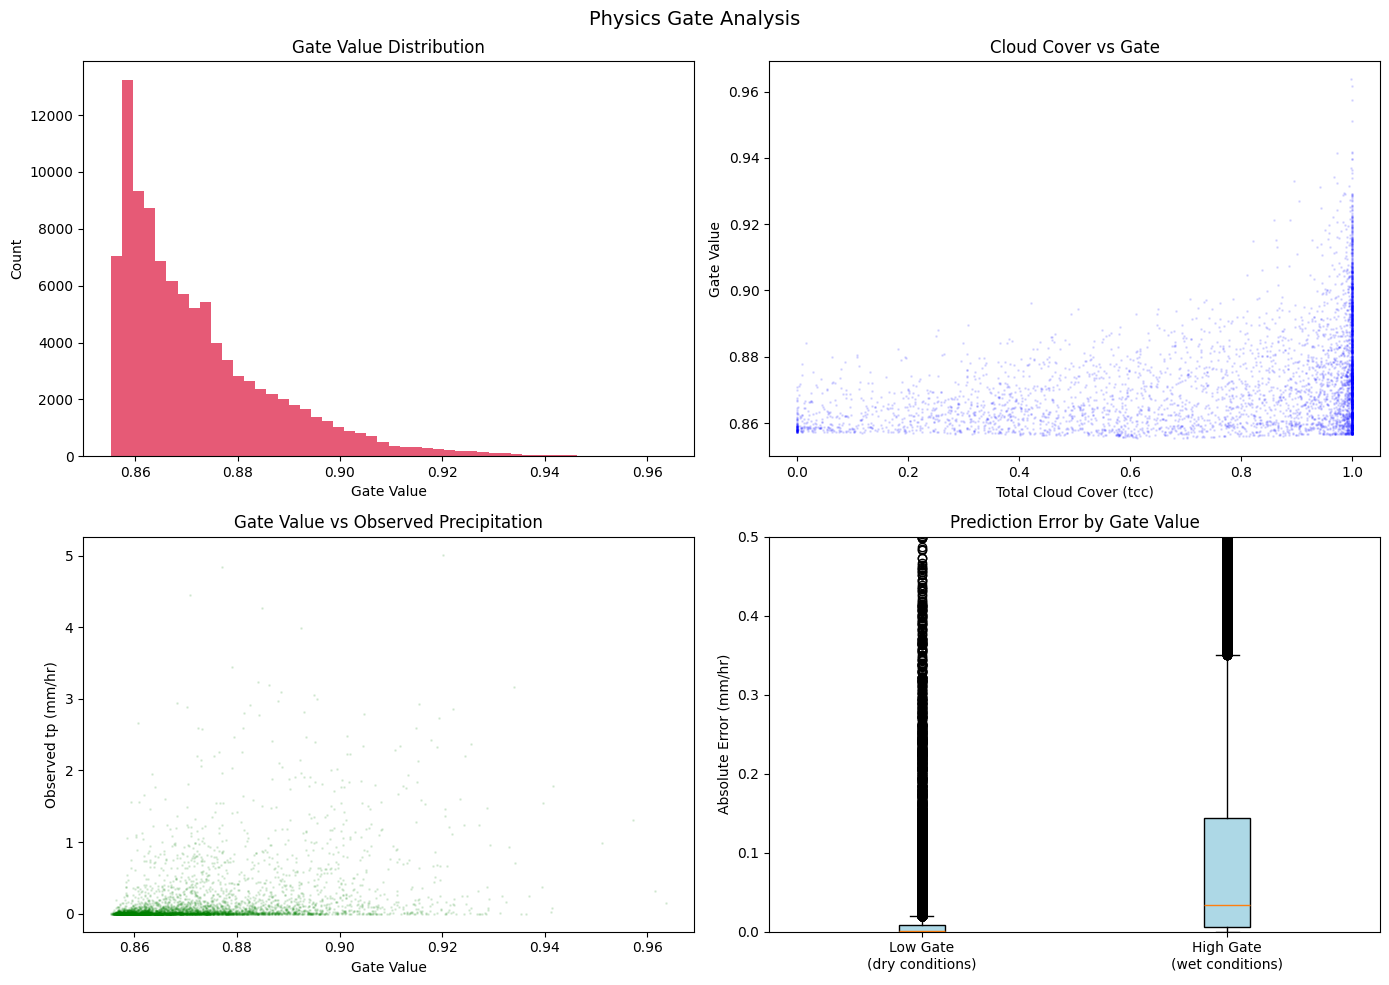

Done!


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：gate值分布
axes[0,0].hist(gates, bins=50, color='crimson', alpha=0.7)
axes[0,0].set_xlabel('Gate Value')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Gate Value Distribution')

# 图2：tcc vs gate散点图
axes[0,1].scatter(tcc_vals[:5000], gates[:5000], alpha=0.1, s=1, color='blue')
axes[0,1].set_xlabel('Total Cloud Cover (tcc)')
axes[0,1].set_ylabel('Gate Value')
axes[0,1].set_title('Cloud Cover vs Gate')

# 图3：gate值 vs 真实降水量
axes[1,0].scatter(gates[:5000], y_sample[:5000]*1000, alpha=0.1, s=1, color='green')
axes[1,0].set_xlabel('Gate Value')
axes[1,0].set_ylabel('Observed tp (mm/hr)')
axes[1,0].set_title('Gate Value vs Observed Precipitation')

# 图4：按gate高低分组的预测误差
gate_low  = gates < np.percentile(gates, 33)
gate_high = gates > np.percentile(gates, 67)

err_low  = np.abs(q50s_orig[gate_low]  - y_sample[gate_low])
err_high = np.abs(q50s_orig[gate_high] - y_sample[gate_high])

axes[1,1].boxplot([err_low*1000, err_high*1000], 
                   labels=['Low Gate\n(dry conditions)', 'High Gate\n(wet conditions)'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[1,1].set_ylabel('Absolute Error (mm/hr)')
axes[1,1].set_title('Prediction Error by Gate Value')
axes[1,1].set_ylim(0, 0.5)

plt.suptitle('Physics Gate Analysis', fontsize=14)
plt.tight_layout()
plt.savefig("/root/gate_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [ ]:
#步骤16：Transformer版本 Physics-guided Quantile Transformer

In [37]:
# 步骤16：Physics-guided Quantile Transformer
import torch
import torch.nn as nn
import math

class PhysicsGuidedQuantileTransformer(nn.Module):
    def __init__(self, input_size=7, d_model=64, nhead=4, 
                 num_layers=2, dropout=0.2):
        super().__init__()
        
        # 输入投影
        self.input_proj = nn.Linear(input_size, d_model)
        
        # 位置编码
        self.pos_encoding = nn.Parameter(torch.randn(12, d_model))
        
        # Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, 
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 物理gate
        self.gate_fc = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
        # 输出头
        self.fc_q10 = nn.Linear(d_model, 1)
        self.fc_q50 = nn.Linear(d_model, 1)
        self.fc_q90 = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x: [batch, 12, 7]
        h = self.input_proj(x) + self.pos_encoding.unsqueeze(0)
        h = self.transformer(h)
        h = h[:, -1, :]  # 取最后时间步
        
        # 物理gate
        tcc_sp = x[:, -1, 4:6]
        gate = self.gate_fc(tcc_sp)
        
        q10 = (self.fc_q10(h) * gate).squeeze(-1)
        q50 = (self.fc_q50(h) * gate).squeeze(-1)
        q90 = (self.fc_q90(h) * gate).squeeze(-1)
        return q10, q50, q90, gate.squeeze(-1)

print("Transformer模型定义完成")

# 训练
model_tf = PhysicsGuidedQuantileTransformer().to(DEVICE)
optimizer_tf = torch.optim.Adam(model_tf.parameters(), lr=3e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_tf.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf.zero_grad()
        q10, q50, q90, gate = model_tf(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_tf.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_tf.state_dict(), "/root/best_transformer.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Transformer模型定义完成
Epoch 1/30 | Train Loss: 0.2986 | Val Loss: 0.2193
  ✓ 保存最优模型 (val_loss=0.2193)
Epoch 2/30 | Train Loss: 0.2772 | Val Loss: 0.2166
  ✓ 保存最优模型 (val_loss=0.2166)
Epoch 3/30 | Train Loss: 0.2738 | Val Loss: 0.2156
  ✓ 保存最优模型 (val_loss=0.2156)
Epoch 4/30 | Train Loss: 0.2718 | Val Loss: 0.2158
Epoch 5/30 | Train Loss: 0.2702 | Val Loss: 0.2146
  ✓ 保存最优模型 (val_loss=0.2146)
Epoch 6/30 | Train Loss: 0.2691 | Val Loss: 0.2149
Epoch 7/30 | Train Loss: 0.2682 | Val Loss: 0.2153
Epoch 8/30 | Train Loss: 0.2674 | Val Loss: 0.2143
  ✓ 保存最优模型 (val_loss=0.2143)
Epoch 9/30 | Train Loss: 0.2668 | Val Loss: 0.2146
Epoch 10/30 | Train Loss: 0.2662 | Val Loss: 0.2148
Epoch 11/30 | Train Loss: 0.2657 | Val Loss: 0.2141
  ✓ 保存最优模型 (val_loss=0.2141)
Epoch 12/30 | Train Loss: 0.2652 | Val Loss: 0.2144
Epoch 13/30 | Train Loss: 0.2647 | Val Loss: 0.2147
Epoch 14/30 | Train Loss: 0.2643 | Val Loss: 0.2143
Epoch 15/30 | Train Loss: 0.2640 | Val Loss: 0.2149
Epoch 16/30 | Train Loss: 0.2636 | Va

In [39]:
# UK Transformer test评估
model_tf.load_state_dict(torch.load("/root/best_transformer.pth"))
model_tf.eval()

test_dataset = RainfallDataset(X_uk, y_uk, test_idx, scaler_X, scaler_y)
test_loader_uk = DataLoader(test_dataset, batch_size=4096, shuffle=False, num_workers=4)

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_uk:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_tf(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s  = np.concatenate(all_q10)
q50s  = np.concatenate(all_q50)
q90s  = np.concatenate(all_q90)
trues = np.concatenate(all_true)

q50_orig  = scaler_y.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(-1)
q10_orig  = scaler_y.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q90_orig  = scaler_y.inverse_transform(q90s.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))

print(f"=== Physics-guided Transformer (UK Test) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")

=== Physics-guided Transformer (UK Test) ===
RMSE: 0.000194 | R²: 0.7151 | Coverage: 0.8176


In [40]:
# Transformer fine-tune on Ireland
model_tf_ft = PhysicsGuidedQuantileTransformer().to(DEVICE)
model_tf_ft.load_state_dict(torch.load("/root/best_transformer.pth"))
optimizer_tf_ft = torch.optim.Adam(model_tf_ft.parameters(), lr=1e-4)

EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(EPOCHS):
    model_tf_ft.train()
    train_loss = 0
    for X_batch, y_batch in ie_train_ft_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer_tf_ft.zero_grad()
        q10, q50, q90, gate = model_tf_ft(X_batch)
        loss = physics_quantile_loss(q10, q50, q90, y_batch, gate)
        loss.backward()
        optimizer_tf_ft.step()
        train_loss += loss.item()
    train_loss /= len(ie_train_ft_loader)

    model_tf_ft.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in ie_val_ft_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            q10, q50, q90, gate = model_tf_ft(X_batch)
            val_loss += physics_quantile_loss(q10, q50, q90, y_batch, gate).item()
    val_loss /= len(ie_val_ft_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_tf_ft.state_dict(), "/root/best_transformer_finetune.pth")
        print(f"  ✓ 保存最优模型 (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停！连续{patience}个epoch没有改善")
            break

print(f"训练完成！最优Val Loss: {best_val_loss:.4f}")

Epoch 1/30 | Train Loss: 0.2676 | Val Loss: 0.2126
  ✓ 保存最优模型 (val_loss=0.2126)
Epoch 2/30 | Train Loss: 0.2660 | Val Loss: 0.2129
Epoch 3/30 | Train Loss: 0.2652 | Val Loss: 0.2132
Epoch 4/30 | Train Loss: 0.2645 | Val Loss: 0.2133
Epoch 5/30 | Train Loss: 0.2642 | Val Loss: 0.2147
Epoch 6/30 | Train Loss: 0.2636 | Val Loss: 0.2145
早停！连续5个epoch没有改善
训练完成！最优Val Loss: 0.2126


In [41]:
model_tf_ft.load_state_dict(torch.load("/root/best_transformer_finetune.pth"))
model_tf_ft.eval()

all_q10, all_q50, all_q90, all_true = [], [], [], []
with torch.no_grad():
    for X_batch, y_batch in ie_test_loader:
        X_batch = X_batch.to(DEVICE)
        q10, q50, q90, gate = model_tf_ft(X_batch)
        all_q10.append(q10.cpu().numpy())
        all_q50.append(q50.cpu().numpy())
        all_q90.append(q90.cpu().numpy())
        all_true.append(y_batch.numpy())

q10s   = np.concatenate(all_q10)
q50s   = np.concatenate(all_q50)
q90s   = np.concatenate(all_q90)
trues  = np.concatenate(all_true)

q10_orig   = scaler_y_ie.inverse_transform(q10s.reshape(-1,1)).reshape(-1)
q50_orig   = scaler_y_ie.inverse_transform(q50s.reshape(-1,1)).reshape(-1)
q90_orig   = scaler_y_ie.inverse_transform(q90s.reshape(-1,1)).reshape(-1)
trues_orig = scaler_y_ie.inverse_transform(trues.reshape(-1,1)).reshape(-1)

rmse     = np.sqrt(np.mean((q50_orig - trues_orig)**2))
r2       = r2_score(trues_orig, q50_orig)
coverage = np.mean((trues_orig >= q10_orig) & (trues_orig <= q90_orig))
pod, far, csi, ext_rmse = extreme_metrics(q50_orig, q90_orig, trues_orig, threshold)

print(f"=== Physics-guided Transformer Fine-tune (Ireland Test) ===")
print(f"RMSE: {rmse:.6f} | R²: {r2:.4f} | Coverage: {coverage:.4f}")
print(f"POD: {pod:.4f} | FAR: {far:.4f} | CSI: {csi:.4f} | Extreme RMSE: {ext_rmse:.6f}")

强降雨样本数: 118716 (5.12%)
=== Physics-guided Transformer Fine-tune (Ireland Test) ===
RMSE: 0.000207 | R²: 0.7033 | Coverage: 0.8324
POD: 0.8867 | FAR: 0.5404 | CSI: 0.4341 | Extreme RMSE: 0.000771


In [42]:
print("=" * 80)
print("完整实验结果汇总表")
print("=" * 80)

results = {
    "UK Training Results": {
        "Deterministic LSTM":        {"RMSE": 0.000193, "R2": 0.7168, "Coverage": "-"},
        "Uncertainty LSTM":          {"RMSE": 0.000224, "R2": 0.6191, "Coverage": "-"},
        "Quantile LSTM":             {"RMSE": 0.000194, "R2": 0.7130, "Coverage": 0.8474},
        "Physics Quantile LSTM":     {"RMSE": 0.000196, "R2": 0.7076, "Coverage": 0.8293},
        "Physics Quantile Transformer": {"RMSE": 0.000194, "R2": 0.7151, "Coverage": 0.8176},
    },
    "Ireland Transfer Results": {
        "Ireland Local Training":          {"RMSE": 0.000210, "R2": 0.6928, "Coverage": 0.8620, "CSI": 0.4254, "FAR": 0.5494},
        "Quantile Zero-shot":              {"RMSE": 0.000208, "R2": 0.6994, "Coverage": 0.8466, "CSI": 0.4349, "FAR": 0.5373},
        "Quantile Fine-tune":              {"RMSE": 0.000209, "R2": 0.6980, "Coverage": 0.8426, "CSI": 0.4310, "FAR": 0.5430},
        "Physics LSTM Zero-shot":          {"RMSE": 0.000210, "R2": 0.6938, "Coverage": 0.8314, "CSI": 0.4356, "FAR": 0.5367},
        "Physics LSTM Fine-tune":          {"RMSE": 0.000209, "R2": 0.6966, "Coverage": 0.8264, "CSI": 0.4365, "FAR": 0.5355},
        "Physics Transformer Fine-tune":   {"RMSE": 0.000207, "R2": 0.7033, "Coverage": 0.8324, "CSI": 0.4341, "FAR": 0.5404},
    }
}

for section, models in results.items():
    print(f"\n{section}")
    print("-" * 70)
    for model, metrics in models.items():
        print(f"{model:<40}", end="")
        for k, v in metrics.items():
            if isinstance(v, float):
                print(f"{k}={v:.4f}  ", end="")
            else:
                print(f"{k}={v}  ", end="")
        print()

print("\n" + "=" * 80)
print("实验完成！")

完整实验结果汇总表

UK Training Results
----------------------------------------------------------------------
Deterministic LSTM                      RMSE=0.0002  R2=0.7168  Coverage=-  
Uncertainty LSTM                        RMSE=0.0002  R2=0.6191  Coverage=-  
Quantile LSTM                           RMSE=0.0002  R2=0.7130  Coverage=0.8474  
Physics Quantile LSTM                   RMSE=0.0002  R2=0.7076  Coverage=0.8293  
Physics Quantile Transformer            RMSE=0.0002  R2=0.7151  Coverage=0.8176  

Ireland Transfer Results
----------------------------------------------------------------------
Ireland Local Training                  RMSE=0.0002  R2=0.6928  Coverage=0.8620  CSI=0.4254  FAR=0.5494  
Quantile Zero-shot                      RMSE=0.0002  R2=0.6994  Coverage=0.8466  CSI=0.4349  FAR=0.5373  
Quantile Fine-tune                      RMSE=0.0002  R2=0.6980  Coverage=0.8426  CSI=0.4310  FAR=0.5430  
Physics LSTM Zero-shot                  RMSE=0.0002  R2=0.6938  Coverage=0.8314  CS